In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer

In [4]:
df = pd.read_csv('./data/nairobi_house_prices.csv')
df.head(10)

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,KSh 350 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres
1,KSh 30 000 000,Vacant Land,Karen,NaN,NaN,NaN,0.5 acres
2,KSh 325 000 000,Vacant Land,Westlands,NaN,NaN,NaN,0.5 acres
3,KSh 80 000 000,Townhouse,Kitisuru,5.0,5.0,NaN,0.5 acres
4,KSh 25 500 000,Apartment,Kileleshwa,4.0,4.0,230 m²,NaN
5,KSh 300 000 000,Townhuse,Runda,6.0,6.0,NaN,0.5 acres
6,KSh 160 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres
7,KSh 9 500 000,Apartment,Kilimani,2.0,2.0,105 m²,NaN
8,KSh 150 000 000,Townhouse,Thigiri,4.0,4.0,NaN,0.5 acres
9,KSh 42 000 000,Apartment,Kileleshwa,4.0,4.0,280 m²,NaN


In [5]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
df.describe()

Shape: (204, 7)

Missing values:
 Price             0
propertyType      0
Location          0
Bedroom          21
bathroom         23
House size      105
Land size       140
dtype: int64

Duplicates: 30


,Bedroom,bathroom
count,183.000000,181.000000
mean,3.513661,2.906077
std,1.585851,1.628570
min,1.000000,1.000000
25%,2.000000,2.000000
50%,4.000000,2.000000
75%,5.000000,4.000000
max,8.000000,8.000000


In [6]:
df.dtypes

Price               str
propertyType        str
Location            str
Bedroom         float64
bathroom        float64
House size          str
Land size           str
dtype: object

In [7]:
df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace(r'[^\d]', '', regex=True)
    .astype('float64')
)

df['House size'] = pd.to_numeric(
    df['House size'].astype(str).str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)

# Drop House size — 105 out of 171 rows are NaN, too unreliable to impute
df = df.drop(columns=['House size'])

In [8]:
df['Land size'] = pd.to_numeric(
    df['Land size'].astype(str).str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)

df.head(10)

,Price,propertyType,Location,Bedroom,bathroom,Land size
0,350000000.0,Townhouse,Runda,4.0,4.0,0.5
1,30000000.0,Vacant Land,Karen,NaN,NaN,0.5
2,325000000.0,Vacant Land,Westlands,NaN,NaN,0.5
3,80000000.0,Townhouse,Kitisuru,5.0,5.0,0.5
4,25500000.0,Apartment,Kileleshwa,4.0,4.0,NaN
5,300000000.0,Townhuse,Runda,6.0,6.0,0.5
6,160000000.0,Townhouse,Runda,4.0,4.0,0.5
7,9500000.0,Apartment,Kilimani,2.0,2.0,NaN
8,150000000.0,Townhouse,Thigiri,4.0,4.0,0.5
9,42000000.0,Apartment,Kileleshwa,4.0,4.0,NaN


In [9]:
df['propertyType'] = df['propertyType'].replace({
    'Townhuse': 'Townhouse',
    'Town house': 'Townhouse'
})

df['propertyType'].value_counts()

propertyType
Apartment              104
Townhouse               79
Vacant Land             19
Commercial Property      1
Industrial Property      1
Name: count, dtype: int64

In [10]:
print("Before:", df.shape)
df = df.drop_duplicates()
print("After:", df.shape)

Before: (204, 6)
After: (155, 6)


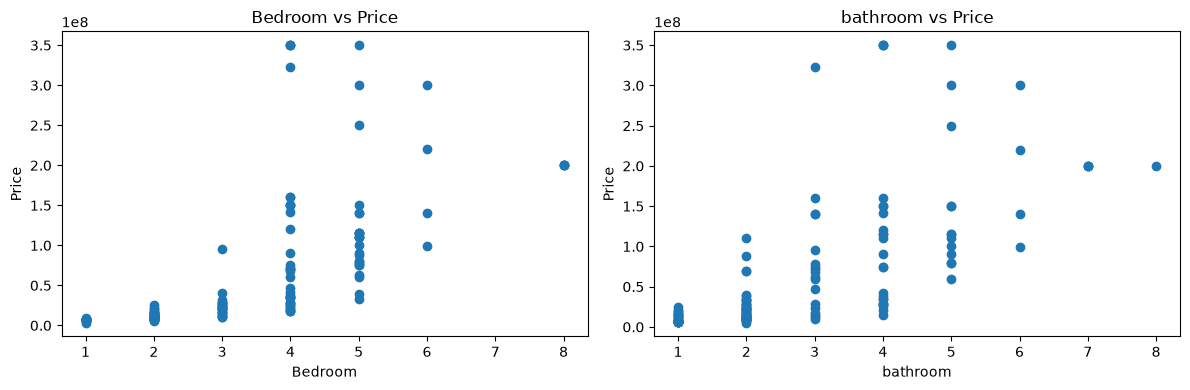

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df['Bedroom'], df['Price'])
axes[0].set_xlabel('Bedroom')
axes[0].set_ylabel('Price')
axes[0].set_title('Bedroom vs Price')

axes[1].scatter(df['bathroom'], df['Price'])
axes[1].set_xlabel('bathroom')
axes[1].set_ylabel('Price')
axes[1].set_title('bathroom vs Price')

plt.tight_layout()
plt.show()

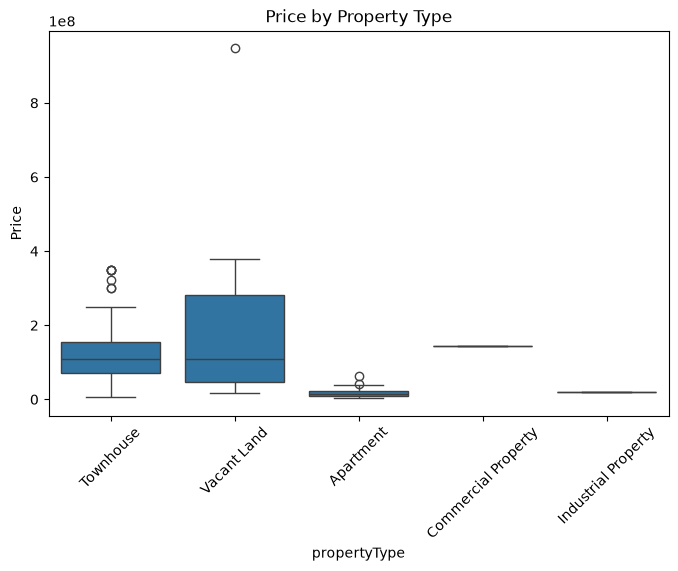

In [12]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x='propertyType', y='Price', data=df)
plt.title('Price by Property Type')
plt.xticks(rotation=45)
plt.show()

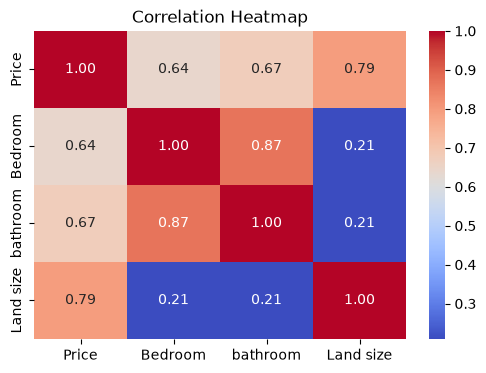

In [13]:
numeric_cols = df[['Price', 'Bedroom', 'bathroom', 'Land size']]
plt.figure(figsize=(6, 4))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [14]:
# Drop locations with fewer than 3 listings to avoid overfitting
location_counts = df['Location'].value_counts()
rare_locations = location_counts[location_counts < 3].index
df = df[~df['Location'].isin(rare_locations)]
print(f"Dropped {len(rare_locations)} rare locations: {list(rare_locations)}")
print(f"Remaining rows: {len(df)}")

df = pd.get_dummies(df, columns=['propertyType', 'Location'], drop_first=True)
df.head()

Dropped 15 rare locations: ['Thigiri', 'Rosslyn', 'Ngong Rd', 'Nairobi West', 'Kyuna', 'Parklands', 'Muthaiga North', 'Muthaiga', 'Kabete', 'Thome', 'Ongata Rongai', 'Lower Kabete', 'Syokimau', 'Mombasa Rd', 'Waithaka']
Remaining rows: 136


,Price,Bedroom,bathroom,Land size,propertyType_Commercial Property,propertyType_Townhouse,propertyType_Vacant Land,Location_Kiambu Road,Location_Kileleshwa,Location_Kilimani,Location_Kitisuru,Location_Lavington,Location_Loresho,Location_Nyari,Location_Riverside,Location_Runda,Location_Westlands
0,350000000.0,4.0,4.0,0.5,False,True,False,False,False,False,False,False,False,False,False,True,False
1,30000000.0,NaN,NaN,0.5,False,False,True,False,False,False,False,False,False,False,False,False,False
2,325000000.0,NaN,NaN,0.5,False,False,True,False,False,False,False,False,False,False,False,False,True
3,80000000.0,5.0,5.0,0.5,False,True,False,False,False,False,True,False,False,False,False,False,False
4,25500000.0,4.0,4.0,NaN,False,False,False,False,True,False,False,False,False,False,False,False,False


In [15]:
numeric_features = ['Bedroom', 'bathroom']

imputer = SimpleImputer(strategy='median')
df[numeric_features] = imputer.fit_transform(df[numeric_features])

# Drop rows where Land size is still NaN
df = df.dropna(subset=['Land size'])

# Log-transform Price to reduce skew (prices range from 8M to 350M)
df['Price'] = np.log1p(df['Price'])

print("Missing values after cleaning:\n", df.isnull().sum())
print(f"\nFinal dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Missing values after cleaning:
 Price                               0
Bedroom                             0
bathroom                            0
Land size                           0
propertyType_Commercial Property    0
propertyType_Townhouse              0
propertyType_Vacant Land            0
Location_Kiambu Road                0
Location_Kileleshwa                 0
Location_Kilimani                   0
Location_Kitisuru                   0
Location_Lavington                  0
Location_Loresho                    0
Location_Nyari                      0
Location_Riverside                  0
Location_Runda                      0
Location_Westlands                  0
dtype: int64

Final dataset: 39 rows, 17 columns


,Price,Bedroom,bathroom,Land size,propertyType_Commercial Property,propertyType_Townhouse,propertyType_Vacant Land,Location_Kiambu Road,Location_Kileleshwa,Location_Kilimani,Location_Kitisuru,Location_Lavington,Location_Loresho,Location_Nyari,Location_Riverside,Location_Runda,Location_Westlands
0,19.673444,4.0,4.0,0.5,False,True,False,False,False,False,False,False,False,False,False,True,False
1,17.216708,3.5,2.0,0.5,False,False,True,False,False,False,False,False,False,False,False,False,False
2,19.599336,3.5,2.0,0.5,False,False,True,False,False,False,False,False,False,False,False,False,True
3,18.197537,5.0,5.0,0.5,False,True,False,False,False,False,True,False,False,False,False,False,False
5,19.519293,6.0,6.0,0.5,False,True,False,False,False,False,False,False,False,False,False,True,False


In [16]:
X = df.drop(columns=['Price'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (31, 16)
Test shape: (8, 16)


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [18]:
y_pred_log = model.predict(X_test_scaled)

# Inverse log transform to get actual KSh values
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

print(f"R² Score: {r2_score(y_test_actual, y_pred):.4f}")
print(f"MAE:      {mean_absolute_error(y_test_actual, y_pred):,.0f}")
print(f"MSE:      {mean_squared_error(y_test_actual, y_pred):,.0f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test_actual, y_pred)):,.0f}")

R² Score: 0.1456
MAE:      70,387,127
MSE:      7,996,159,506,429,641
RMSE:     89,421,248


In [19]:
comparison = pd.DataFrame({
    'Actual': y_test_actual.values,
    'Predicted': y_pred
})
comparison.head(10)

,Actual,Predicted
0,143000000.0,1.361953e+07
1,180000000.0,1.098118e+08
2,300000000.0,1.260195e+08
3,38000000.0,5.802825e+07
4,200000000.0,1.243373e+08
5,8500000.0,1.635772e+07
6,115000000.0,1.907769e+08
7,6500000.0,1.672219e+07


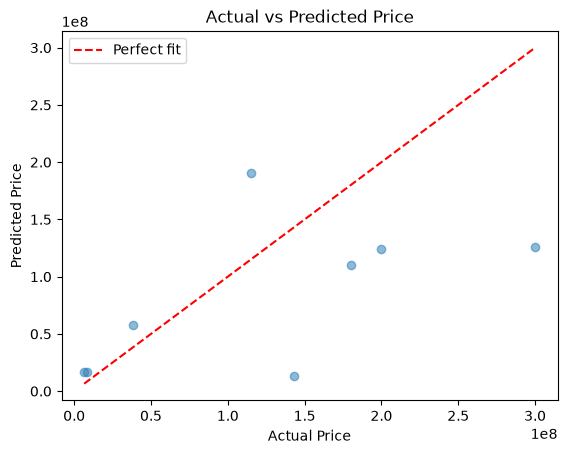

In [20]:
plt.scatter(y_test_actual, y_pred, alpha=0.5)
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'r--', label='Perfect fit')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.legend()
plt.show()

## Model Comparison

Below we train and compare three families of models on the cleaned, log-transformed dataset:

1. **Linear Regression** — a plain multiple linear regression on the standardized features.
2. **Polynomial Regression** — adds polynomial interaction/degree terms to capture non-linear relationships.
3. **Regularized models (Ridge & Lasso)** — linear models with an L2/L1 penalty to control overfitting.

All models are evaluated on the same held-out test split using R², MAE and RMSE (reported in real KSh by reversing the log-transform).

In [21]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Collect every model's metrics for a final side-by-side comparison
results = []

def evaluate_model(name, model, Xtr, Xte, ytr, yte):
    """Fit a model, predict on the test set, and store/evaluate metrics in KSh."""
    model.fit(Xtr, ytr)
    y_pred_log = model.predict(Xte)
    y_pred = np.expm1(y_pred_log)          # back to KSh
    y_test_actual = np.expm1(yte)          # back to KSh
    r2 = r2_score(y_test_actual, y_pred)
    mae = mean_absolute_error(y_test_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    results.append({
        'Model': name,
        'R2': round(r2, 4),
        'MAE': int(round(mae)),
        'RMSE': int(round(rmse))
    })
    print(f"{name:24s} R2={r2:8.4f}  MAE={mae:15,.0f}  RMSE={rmse:15,.0f}")

### 1. Linear Regression
A standard multiple linear regression on the standardized features (no penalty).

In [22]:
evaluate_model(
    'Linear Regression',
    LinearRegression(),
    X_train_scaled, X_test_scaled, y_train, y_test
)

Linear Regression        R2=  0.1204  MAE=     69,485,055  RMSE=     90,729,247


### 2. Polynomial Regression
`PolynomialFeatures` expands the numeric features into polynomial and interaction terms up to a given degree. The features are scaled **after** the expansion. With only ~39 training rows we expect higher degrees to overfit, so we test degrees 2 and 3.

In [23]:
for deg in [2, 3]:
    poly_model = make_pipeline(
        PolynomialFeatures(degree=deg, include_bias=False),
        StandardScaler(),
        LinearRegression()
    )
    evaluate_model(
        f'Polynomial (deg {deg})',
        poly_model,
        X_train, X_test, y_train, y_test
    )

Polynomial (deg 2)       R2= -1.6395  MAE=    131,027,558  RMSE=    157,173,745
Polynomial (deg 3)       R2= -0.4016  MAE=    100,528,634  RMSE=    114,533,934


### 3. Regularization (Ridge & Lasso)
Regularized regression penalizes large coefficients to reduce overfitting. We sweep the penalty strength `alpha` for both the L2-regularized **Ridge** and the L1-regularized **Lasso**.

In [24]:
alphas = [0.1, 1, 10, 100, 1000]
for a in alphas:
    evaluate_model(
        f'Ridge (a={a})',
        Ridge(alpha=a),
        X_train_scaled, X_test_scaled, y_train, y_test
    )
    evaluate_model(
        f'Lasso (a={a})',
        Lasso(alpha=a, max_iter=100_000),
        X_train_scaled, X_test_scaled, y_train, y_test
    )

Ridge (a=0.1)            R2=  0.1240  MAE=     69,650,866  RMSE=     90,547,929
Lasso (a=0.1)            R2=  0.0282  MAE=     76,925,943  RMSE=     95,366,270
Ridge (a=1)              R2=  0.1456  MAE=     70,387,127  RMSE=     89,421,248
Lasso (a=1)              R2= -0.2581  MAE=     91,942,741  RMSE=    108,509,782
Ridge (a=10)             R2=  0.1985  MAE=     69,350,593  RMSE=     86,611,381
Lasso (a=10)             R2= -0.2581  MAE=     91,942,741  RMSE=    108,509,782
Ridge (a=100)            R2=  0.0931  MAE=     73,886,709  RMSE=     92,130,687
Lasso (a=100)            R2= -0.2581  MAE=     91,942,741  RMSE=    108,509,782
Ridge (a=1000)           R2= -0.1842  MAE=     89,058,940  RMSE=    105,276,950
Lasso (a=1000)           R2= -0.2581  MAE=     91,942,741  RMSE=    108,509,782


### 4. Summary Comparison
Finally, we bring every model together, sort by RMSE, and visualise the results.

In [25]:
comparison = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
comparison["MAE (KSh M)"] = comparison["MAE"] / 1e6
comparison["RMSE (KSh M)"] = comparison["RMSE"] / 1e6
comparison[["Model", "R2", "MAE (KSh M)", "RMSE (KSh M)"]]

,Model,R2,MAE (KSh M),RMSE (KSh M)
0,Ridge (a=10),0.1985,69.350593,86.611381
1,Ridge (a=1),0.1456,70.387127,89.421248
2,Ridge (a=0.1),0.1240,69.650866,90.547929
3,Linear Regression,0.1204,69.485055,90.729247
4,Ridge (a=100),0.0931,73.886709,92.130687
5,Lasso (a=0.1),0.0282,76.925943,95.366270
6,Ridge (a=1000),-0.1842,89.058940,105.276950
7,Lasso (a=1),-0.2581,91.942741,108.509782
8,Lasso (a=10),-0.2581,91.942741,108.509782
9,Lasso (a=100),-0.2581,91.942741,108.509782


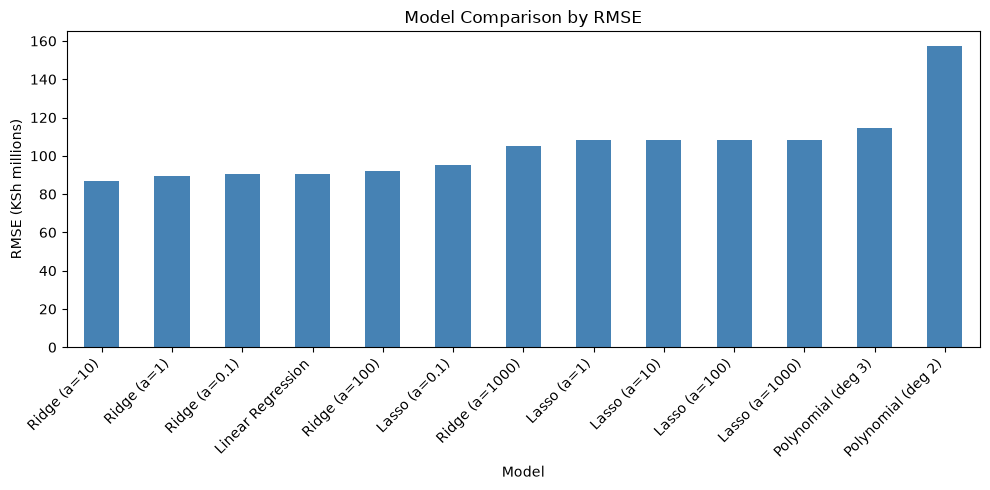

In [26]:
plt.figure(figsize=(10, 5))
axes = plt.gca()
comparison.sort_values('RMSE').plot.bar(
    x='Model', y='RMSE (KSh M)', ax=axes, legend=False, color='steelblue'
)
plt.ylabel('RMSE (KSh millions)')
plt.xticks(rotation=45, ha='right')
plt.title('Model Comparison by RMSE')
plt.tight_layout()
plt.show()

### Findings

- **Regularization wins on this dataset.** A **Ridge** model with `alpha=10` is the best performer (highest R² ≈ 0.20, lowest RMSE ≈ 86.6M KSh), beating plain linear regression.
- **Lasso** performs noticeably worse and its coefficients collapse to a flat prediction as `alpha` increases (the L1 penalty zeroes too many features on this small dataset).
- **Polynomial regression overfits badly.** The higher degrees explode variance with only ~39 training rows and large numbers of generated features, producing negative R² on the test set.

Overall, the dataset is small and noisy, so no model reaches a high R². Ridge regularisation gives the most stable and best generalising result.